**Idea:** Compare putative collision trials to a distribution of non-collision trials $P$ and ask - are they outliers?

For each cell, define its antidromic "footprint"
- channels that it would plausibly be on (based on the waveform template)
- timebins that antidromic response could occur (based on the antidromic worms)

Collect footprints from putative collision trials (spontaneous spike within t_max of stim event) and non-collision trials (no spike near stim)

Estimate the distribution $P_{hat}$ of the non-collision trials.

Are the collision trials outliers?

In [1]:
import numpy as np

from scipy import stats
from scipy.spatial import distance as dist

import matplotlib.pyplot as plt

import format_chronic_stim
import stim_plots

import sys
sys.path.append("..//neural/")
import format_waveform_data
import wormhole_analysis as analysis

import scipy.io
import os

In [2]:
''' set paths '''
# set parent directory
# root_dir = "Z:/Isabel/data/hpc_implants/" # locker
# root_dir = "../data/antidromic_stim/" # local
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "SLV132"
session_id = "250310"
ephys_id = "SLV132_250310_122522"
stim_pol = "neg250"
show_plots = True
only_good = True

# data dirs
# session_dir = f"{root_dir}{bird_id}/{bird_id}_{session_id}/{ephys_id}/" # locker
# session_dir = f"{root_dir}{bird_id}/{bird_id}_{session_id}/" # local
session_dir = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/" # local
ks_dir = "kilosort4_blanked_short/"
ephys_dir = f"{session_dir}raw_ephys_output/"

In [3]:
''' basic params '''
sampling_rate = 30000
t_pre = 0.02 # seconds collected before stim starts
t_post = 0.03 # seconds collected after stim time

# font sizes
title_size = 14
axis_label = 12
tick_label = 9

In [4]:
''' load and preprocess the stim data '''
raw_ephys = format_chronic_stim.load_stim(ephys_dir, stim_pol=stim_pol)
sorted_ephys, ch_names = format_chronic_stim.sort_stim_by_channel(ephys_dir, raw_ephys)
[n_channels, n_samples, n_stim] = sorted_ephys.shape

# get the stim times
stim_times = np.load(f'{ephys_dir}stim_t_{stim_pol}.npy')
stim_times = np.squeeze(stim_times.astype(int))

assert(stim_times.shape[0]==n_stim)

loaded 623 stim events in 0.07525739999255165 seconds
C:/Users/Isabel/Documents/data_temp/SLV132_250310/SLV132_250310_122522/raw_ephys_output/intan_info.mat


In [5]:
broken_channels = np.asarray([53, 56, 63]) 
for ch in broken_channels:
    print(ch_names[ch])

B-15-3
B-17-3
B-22-2


In [6]:
start_idx = 0
end_idx = n_stim

ephys_data, ch_names = format_chronic_stim.trim_stim_data(sorted_ephys, ch_names,
                                                          broken_ch=broken_channels,
                                                          start_idx=start_idx, end_idx=end_idx)

# get indices for each shank
A_shank = []
B_shank = []
for i, ch in enumerate(ch_names):
    if 'A' in ch:
        A_shank.append(i)
    else:
        B_shank.append(i)
A_shank = np.asarray(A_shank)
B_shank = np.asarray(B_shank)

# data params
[n_channels, n_samples, n_stim] = ephys_data.shape
stim_times = stim_times[start_idx:end_idx]
assert(stim_times.shape[0]==n_stim)
print(f"n channels = {n_channels}, samples = {n_samples}, stim events = {n_stim}")

n channels = 61, samples = 1500, stim events = 623


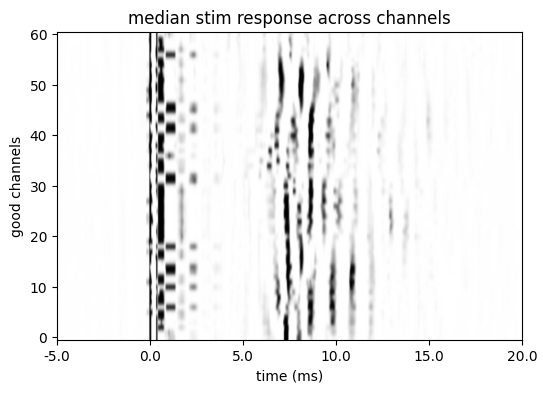

In [7]:
''' filter stim data and plot median stim event for all channels '''
filt_data = format_chronic_stim.filter_stim_for_spikes(ephys_data)
if show_plots:
    f, ax = stim_plots.plot_avg_stim(filt_data, v_max=40)
    plt.show()

In [8]:
''' load and format the waveform struct '''
waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
wf_ids = waveform_struct['goodIDs']
mean_waveforms, wf_channels, _ = format_waveform_data.sort_wf_by_channel('', waveform_struct,
                                                                                 data_dir=ephys_dir)

# only good
if only_good==True:
    good_idx = np.asarray([i for i, label in enumerate(waveform_struct['goodLabels']) if label == 'good'])
    wf_ids = wf_ids[good_idx]
    mean_waveforms = mean_waveforms[good_idx]
    wf_channels_tmp = []
    for g_idx in good_idx.astype(int):
        wf_channels_tmp.append(wf_channels[g_idx])
    wf_channels = wf_channels_tmp

# filter out the bad channels and get the new channel index
all_ch = np.arange(mean_waveforms.shape[1])
good_idx = np.setdiff1d(all_ch, broken_channels)
mean_waveforms = mean_waveforms[:, good_idx]
wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])

n_cells = mean_waveforms.shape[0]

C:/Users/Isabel/Documents/data_temp/SLV132_250310/SLV132_250310_122522/kilosort4_blanked_short/waveformStruct.mat
C:/Users/Isabel/Documents/data_temp/SLV132_250310/SLV132_250310_122522/raw_ephys_output/intan_info.mat


In [9]:
good_clusters, spike_id, spike_t = format_waveform_data.get_spike_times(session_dir, ks_dir=ks_dir)
assert good_clusters.shape[0] == n_cells

In [10]:
pre_stim_spikes = analysis.get_near_stim_spikes(stim_times, spike_id, spike_t,
                                                hash_start_t=5e-3, hash_end_t=20e-3, sampling_rate=sampling_rate)

In [12]:
'''
get the hash - consistent antidromic responses to stim 
crop to a range that captures all antidromic responses
'''
buffer = 6
start_t = 5e-3
end_t = 15e-3
start_idx = np.round((t_pre + start_t)*sampling_rate).astype(int)
end_idx = np.round((t_pre + end_t)*sampling_rate).astype(int)

# select time window and re-order axes to be shape (n_trials, n_channels, n_samples)
stim_hash = np.moveaxis(filt_data[:, start_idx:end_idx], -1, 0)
n_samp = stim_hash.shape[-1]
avg_hash = np.mean(stim_hash, axis=0)
print(avg_hash.shape)

# cropping params
spk_thresh = 25 # minimum spike amplitude in uV
spk_half_samp = 6 # n samples to include on each side of the spike
spk_half_ch = 4 # n channels to include on each side of the spike

#  define mask
mask = np.zeros_like(avg_hash).astype(bool)
for i in range(n_channels):
    for j in range(n_samp):
        if np.abs(avg_hash[i, j]) >= spk_thresh:
            ch_start = np.max([i-spk_half_ch, 0])
            ch_end = np.min([i+spk_half_ch+1, n_channels])
            samp_start = np.max([j-spk_half_samp, 0])
            samp_end = np.min([j+spk_half_samp+1, n_samp])
            mask[ch_start:ch_end, samp_start:samp_end] = True
            
# define channels with an antidromic response (worm)
worm_ch_idx = np.zeros(n_channels).astype(bool)
for i in range(n_channels):
    if any(np.abs(avg_hash[i]) >= spk_thresh):
        worm_ch_idx[i] = True
worm_channels = np.arange(n_channels)[worm_ch_idx]

(61, 300)


<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Isabel\AppData\Local\Temp\ipykernel_20256\2338278904.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'cropping mask, spike threshold = {spk_thresh} $\mu$V')


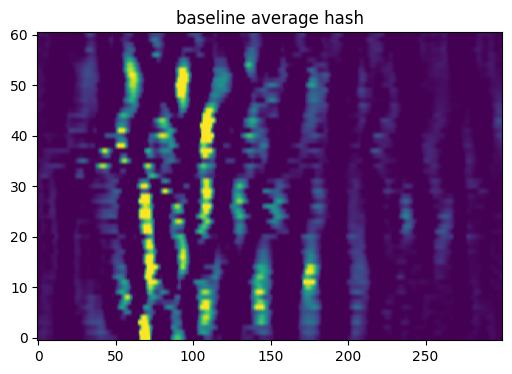

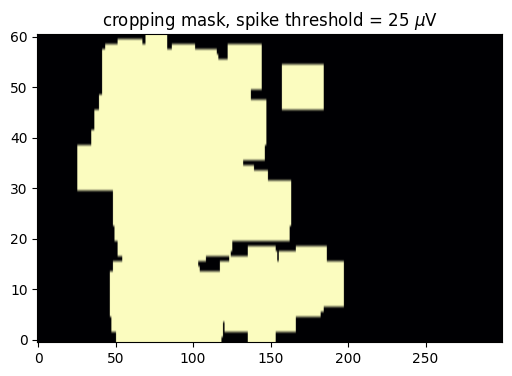

In [13]:
''' plot the raw hash and the clipping mask '''
f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.imshow(-avg_hash, clim=[0, 50],
          aspect='auto', cmap='viridis')
ax.set_title('baseline average hash')
ax.set_ylim(ax.get_ylim()[::-1])
plt.show()

f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.imshow(mask, clim=[0, 1],
          aspect='auto', cmap='magma')
ax.set_title(f'cropping mask, spike threshold = {spk_thresh} $\mu$V')
ax.set_ylim(ax.get_ylim()[::-1])
plt.show()

In [21]:
''' Grab the "footprint" for each cell '''
np.squeeze(mean_waveforms[good_clusters==266]).shape

(61, 120)

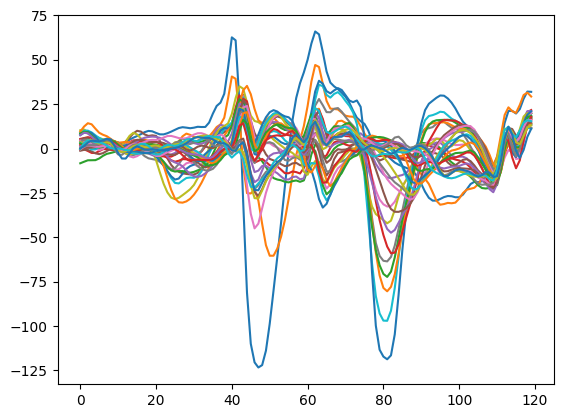

In [33]:
plt.plot(np.squeeze(mean_waveforms[good_clusters==108, 30:]).T)
# plt.ylim(-80, 80)
plt.show()

In [ ]:
def subsample_channels(best_ch, A_shank=np.arange(32),
                        B_shank=np.arange(32, 64), wf_thresh=20):
    '''
    Modify subsample channels to choose channel range based on a voltage threshold
    
    Gets channel indices centered on the best channel (best_ch) for a 
    given waveform. Shifts this index as-needed to stay on the same shank as the
    best channel and avoid going past shank ends.

    

    A_shank and B_shank define the channel indices on each shank.
    '''
    if best_ch - n_wf_ch//2 < 0: # near tip of A
        hash_ch_idx = np.arange(n_wf_ch)
    elif (best_ch <= A_shank[-1]) & (best_ch + n_wf_ch//2 > A_shank[-1]): # near top of A
        hash_ch_idx = np.arange(A_shank[-1] - n_wf_ch, A_shank[-1])
    elif (best_ch > A_shank[-1]) & (best_ch - n_wf_ch//2 <= A_shank[-1]): # near tip of B
        hash_ch_idx = np.arange(B_shank[0], B_shank[0] + n_wf_ch)
    elif best_ch + n_wf_ch//2 > B_shank[-1]: # near top of B
        hash_ch_idx = np.arange(B_shank[-1] - n_wf_ch, B_shank[-1])
    else: # mid-shank
        hash_ch_idx = np.arange(best_ch - n_wf_ch//2, best_ch + n_wf_ch//2 + 1)
        
    return hash_ch_idx

In [ ]:
'''
Example cells to try:
266
- very plausible collision cell
- p < 0.01 for both stim powers
- ~6-7% of trials are potential collision trials
- ks finds it in the hash and latencies are tight, collisions are compelling with this method, too

303
- very plausible collision cell
- large spike but overlapping hash
- p < 0.01 both stim powers
- ~3% of trials are potential collisions

191
- plausible collision cell
- p < 0.01 for both stim powers 
- very few collision trials (1-4 ish...)
- strangley coupled to another antidromic spike - could be false positive due to recurrence?

323
- found using ks-detected waveform in hash
- collision detection seems not to work?
- similar (same?) spike nearby in time on some collision trials
- suspisciously high number of no spike/off-latency trials - maybe stopped responding?

549
- found using ks-detected waveform in hash (very tight latencies)
- seems unreliable (10% of trials doesn't spike or off-latency)
- ~10% of trials are putative collisions (long latency)
- unclear if collision or not

need false positive
518
- lots of possible collision trials
- no apparent collision happening
'''